# Prophet による時系列予測

Metaの `prophet` ライブラリを使用して時系列予測を行います。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.extract import extract_data
from src.transfform import transform_data

plt.style.use("seaborn-v0_8-whitegrid")

raw_path = Path("data/raw/data.csv")
df = transform_data(extract_data(raw_path))

series = (
    df.set_index("date")["temp_avg"]
    .asfreq("D")
    .astype(float)
    .interpolate(method="time")
)

train_size = len(series) - 30
train = series.iloc[:train_size]
test = series.iloc[train_size:]

# Prophetは 'ds' (日付) と 'y' (予測対象) というカラム名を持つDataFrameを要求します
df_train = train.reset_index().rename(columns={"date": "ds", "temp_avg": "y"})
df_test = test.reset_index().rename(columns={"date": "ds", "temp_avg": "y"})

print(f"train shape: {df_train.shape}, test shape: {df_test.shape}")


Importing plotly failed. Interactive plots will not work.


抽出後のカラム:
['年月日', '平均気温(℃)', '最高気温(℃)', '最低気温(℃)']
変換後のデータの最初の3行は
        年月日 平均気温(℃)       date  temp_avg
0  2025/1/1     5.9 2025-01-01       5.9
1  2025/1/2     6.2 2025-01-02       6.2
2  2025/1/3     6.4 2025-01-03       6.4
train shape: (335, 2), test shape: (30, 2)


In [2]:
# Prophet モデルの構築と学習
# 日次データで1年未満のデータ（約1年分）のため、yearly_seasonalityを有効にします
model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
model.fit(df_train)


17:10:11 - cmdstanpy - INFO - Chain [1] start processing
17:10:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE=8.049, RMSE=8.632


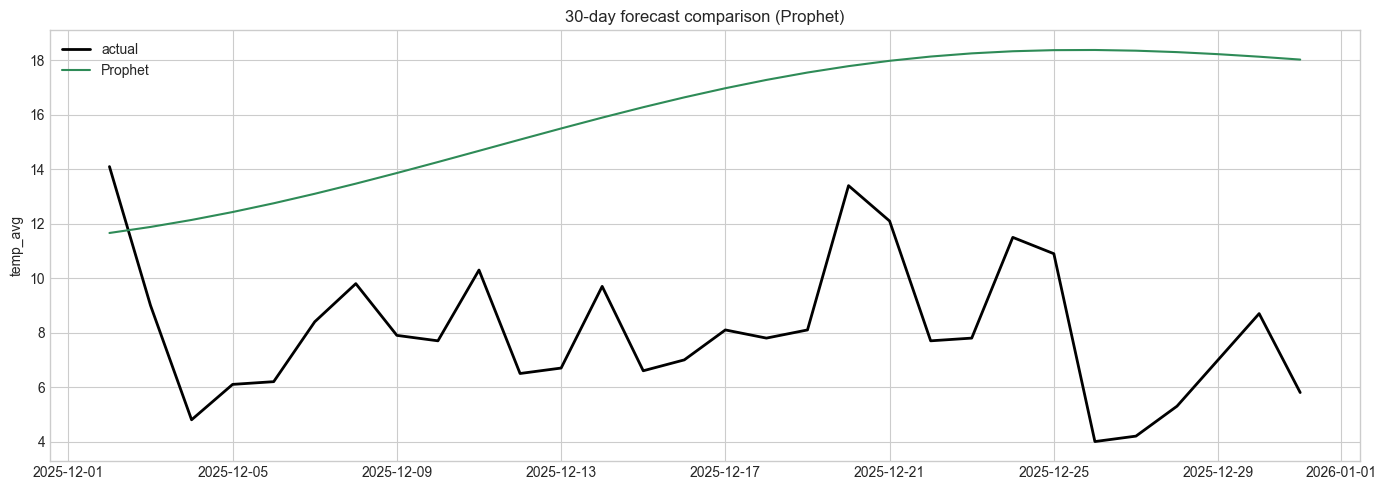

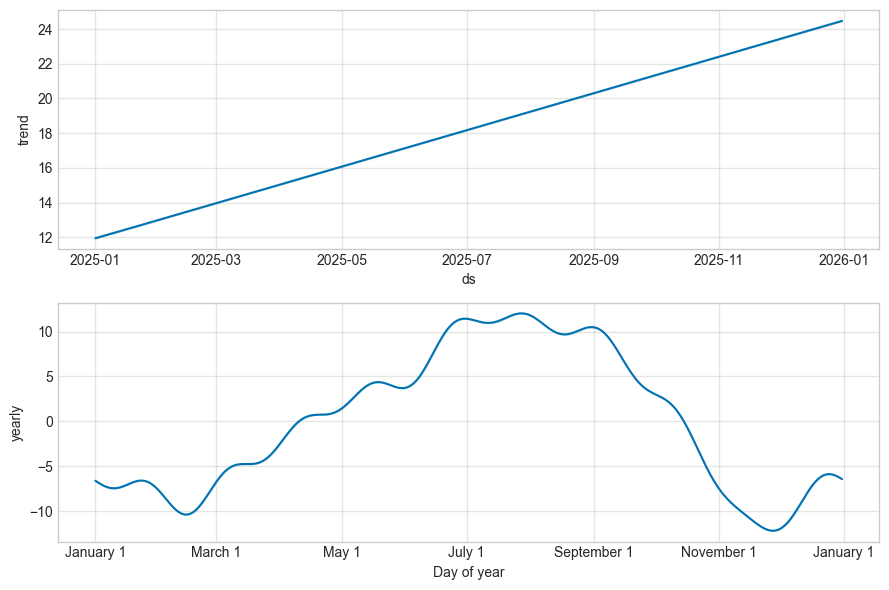

In [3]:
# 予測と評価
# 予測用の未来の日付データフレームを作成
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# テスト期間の予測値を抽出
prophet_forecast = forecast.iloc[-30:]["yhat"].values

def score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

prophet_mae, prophet_rmse = score(test.values, prophet_forecast)
print(f"Prophet -> MAE={prophet_mae:.3f}, RMSE={prophet_rmse:.3f}")

# プロット
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label="actual", color="black", linewidth=2)
ax.plot(test.index, prophet_forecast, label="Prophet", color="seagreen")
ax.set_title("30-day forecast comparison (Prophet)")
ax.set_ylabel("temp_avg")
ax.legend()
plt.tight_layout()
plt.show()

# Prophetの成分（トレンド、季節性など）のプロット
fig_comp = model.plot_components(forecast)
plt.show()
